# Project 2 — Notebook 07: Fault Anatomy
### RFO Distribution and NE Category Breakdown by Zone

---

**Questions this notebook answers:**
1. Which fault categories dominate each zone? Do Zone 5 and Zone 6 have a distinct
   fault type fingerprint — or is elevated field time purely a capacity/permit issue?
2. Which network element categories drive the longest field resolution times?
   Does the NE mix differ by zone in a way that explains performance gaps?

> **Columns used:** `Standardized RFO`, `NE_Category`, `ZONE`, `FIELD_TIME_HOURS`,
> `OUTAGEDURATION`, `SLA_Compliant`, `Timestamp_Integrity`

## 1. Setup
from fault_ticket_plots import plot_dual_barh

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import ZONE_ORDER, ZONE_PALETTE, RFO_PALETTE, PROFESSIONAL_PALETTE
from src.visualization import plot_dual_barh

df = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[df['ZONE'].isin(ZONE_ORDER)].copy()

ZONE_COLORS = ZONE_PALETTE

print(f"✅ {len(df_zone):,} zoned tickets")
print(f"   Unique RFOs     : {df_zone['Standardized RFO'].nunique()}")
print(f"   NE Categories   : {df_zone['NE_Category'].nunique()} — {sorted(df_zone['NE_Category'].unique())}")
print(f"   RFO top 5:\n{df_zone['Standardized RFO'].value_counts().head()}")

✅ 36,907 zoned tickets
   Unique RFOs     : 25
   NE Categories   : 6 — ['Access', 'Core Network', 'Data Services', 'IP/Network Infra', 'Network Management', 'Transport']
   RFO top 5:
Standardized RFO
FACILITIES-Power Failure             13055
EQUIPMENT-Defective Hardware          7921
UNKNOWN-Under Investigation           5129
FOC CUT - LINEAR                      3735
FACILITIES-Cooling System Problem     2136
Name: count, dtype: int64


## 2. RFO Distribution — NCR Wide

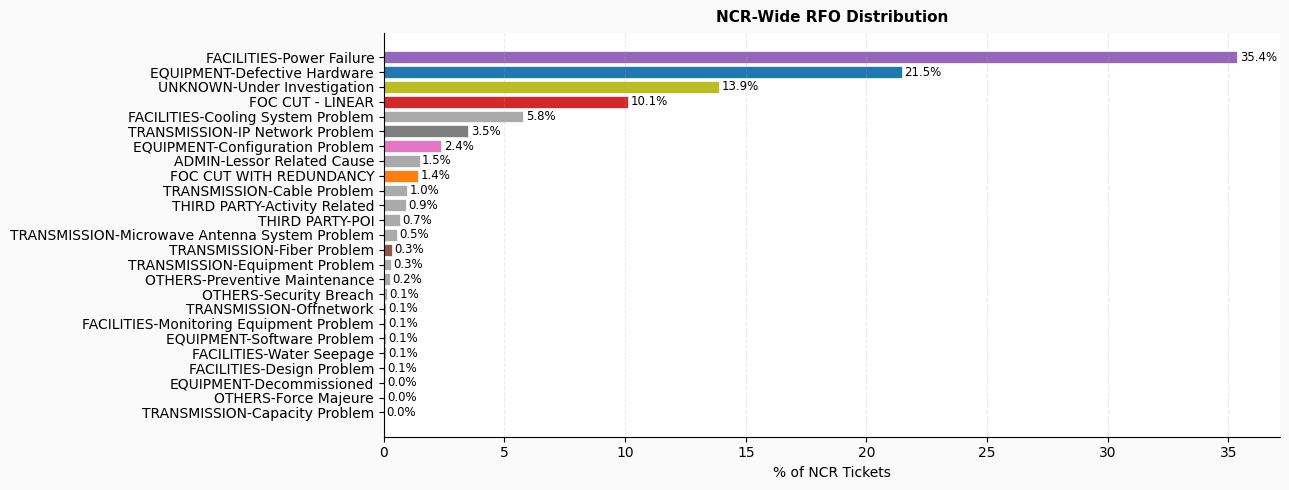

In [2]:
ncr_rfo = (df_zone['Standardized RFO'].value_counts()
            .reset_index()
            .rename(columns={'Standardized RFO': 'RFO', 'count': 'Count'}))
ncr_rfo['Pct'] = ncr_rfo['Count'] / ncr_rfo['Count'].sum() * 100

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')

colors = [RFO_PALETTE.get(r, '#aaa') for r in ncr_rfo['RFO']]
bars = ax.barh(ncr_rfo['RFO'], ncr_rfo['Pct'], color=colors, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, ncr_rfo['Pct']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8.5)

ax.set_xlabel('% of NCR Tickets', fontsize=10)
ax.set_title('NCR-Wide RFO Distribution', fontsize=11, fontweight='bold', pad=8)
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.25, linestyle='--')

plt.tight_layout()
os.makedirs('reports/figures/project2_ncr', exist_ok=True)
plt.savefig('reports/figures/project2_ncr/07_ncr_rfo_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Top-5 RFOs by Zone — Heatmap

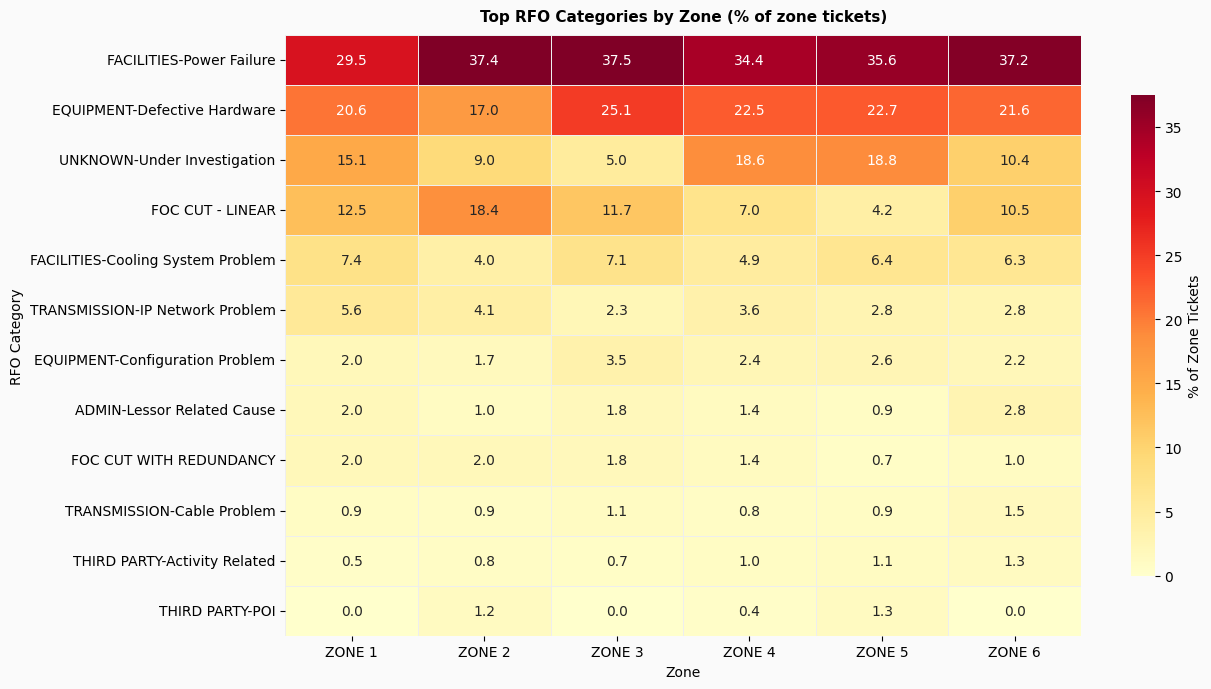

In [3]:
# Pivot: Zone × RFO as % of that zone's total tickets
rfo_zone = (df_zone.groupby(['ZONE', 'Standardized RFO'])
             .size()
             .reset_index(name='Count'))
rfo_zone['Zone_Total'] = rfo_zone.groupby('ZONE')['Count'].transform('sum')
rfo_zone['Pct'] = rfo_zone['Count'] / rfo_zone['Zone_Total'] * 100

# Top RFOs by total NCR volume — use top 10 for heatmap
top_rfos = (df_zone['Standardized RFO'].value_counts().head(12).index.tolist())

pivot = (rfo_zone[rfo_zone['Standardized RFO'].isin(top_rfos)]
         .pivot_table(index='Standardized RFO', columns='ZONE',
                      values='Pct', fill_value=0)
         .reindex(columns=ZONE_ORDER))
pivot = pivot.reindex(top_rfos)

from src.visualization.common_plots import plot_heatmap
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#fafafa')

plot_heatmap(ax, pivot, pivot=False,
             title='Top RFO Categories by Zone (% of zone tickets)',
             cmap='YlOrRd', fmt='.1f',
             cbar_label='% of Zone Tickets', cbar_shrink=0.8,
             x_label='Zone', y_label='RFO Category',
             x_rotation=0, y_rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/07_rfo_zone_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. RFO vs Field Time — Which Fault Types Are Slowest to Resolve?

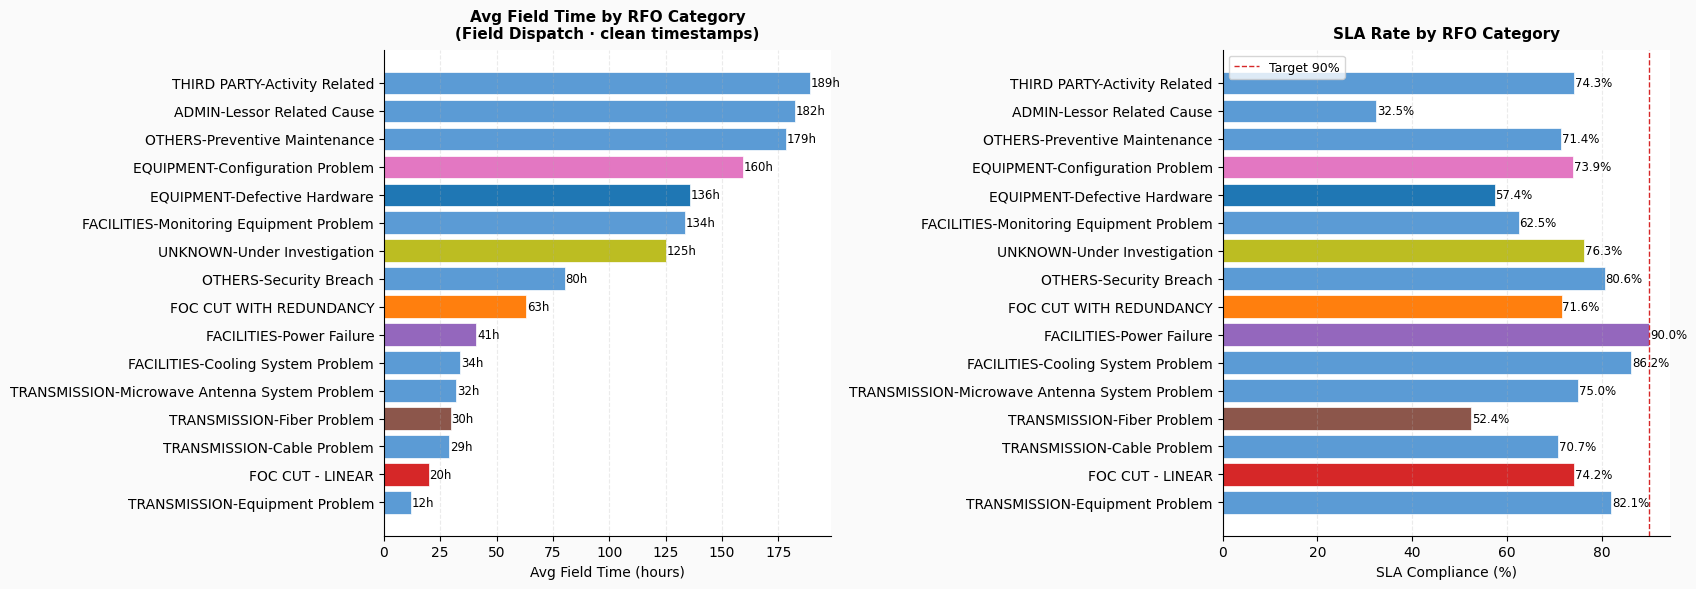

In [4]:
# Mean field time per RFO — timestamp-clean Field_Dispatch tickets only
clean_fd = df_zone[
    (df_zone['Resolution_Path'] == 'Field_Dispatch_Restored') &
    (df_zone['Timestamp_Integrity'])
].copy()

rfo_field = (clean_fd.groupby('Standardized RFO')
              .agg(
                  Avg_Field_Time=('FIELD_TIME_HOURS', 'mean'),
                  Ticket_Count=('FIELD_TIME_HOURS', 'count'),
                  SLA_Rate=('SLA_Compliant', 'mean')
              )
              .reset_index()
              .sort_values('Avg_Field_Time', ascending=False))

# Filter to RFOs with meaningful volume (>= 30 tickets)
rfo_field = rfo_field[rfo_field['Ticket_Count'] >= 30]
rfo_field['SLA_Rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.patch.set_facecolor('#fafafa')
plot_dual_barh(
    axes[0], axes[1], rfo_field,
    label_col='Standardized RFO',
    time_col='Avg_Field_Time', sla_col='SLA_Rate',
    time_xlabel='Avg Field Time (hours)', sla_xlabel='SLA Compliance (%)',
    title_left='Avg Field Time by RFO Category\n(Field Dispatch · clean timestamps)',
    title_right='SLA Rate by RFO Category',
    palette=[RFO_PALETTE.get(r, '#5b9bd5') for r in rfo_field['Standardized RFO']],
)
plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/07_rfo_field_time_sla.png', dpi=150, bbox_inches='tight')
plt.show()


## 4b. RFO vs NOC Time — Which Fault Types Hold Longest Before Field Dispatch?

> **`DISPATCH_DELAY_HOURS`** = `REPORTDATE` → `DISPATCHDATE` (NOC endorsement timestamp).
> This captures NOC triage time **plus** the contact and escalation chain under the
> operations team strategy: NOC calls the assigned engineer up to 3 times; if unreachable,
> escalates to the duty team lead; if still unreachable, escalates to the area head.
> `DISPATCHDATE` is stamped at the point NOC successfully endorses the ticket — not
> when the engineer physically departs for site.
>
> **Important:** Mobilisation delay does not end at `DISPATCHDATE`. Once the assigned
> engineer receives the call (on day-off), they must locate and brief the duty engineer
> or coordinate with the team lead — who may also be managing their own assigned sites.
> This coordination overhead flows into **`FIELD_TIME_HOURS`** and is not captured here.
> `DISPATCH_DELAY_HOURS` and `FIELD_TIME_HOURS` together form the full mobilisation picture
> for day-off scenarios; neither metric alone isolates the endorsement friction.
>
> Timestamp-clean tickets only (`Timestamp_Integrity = True`).

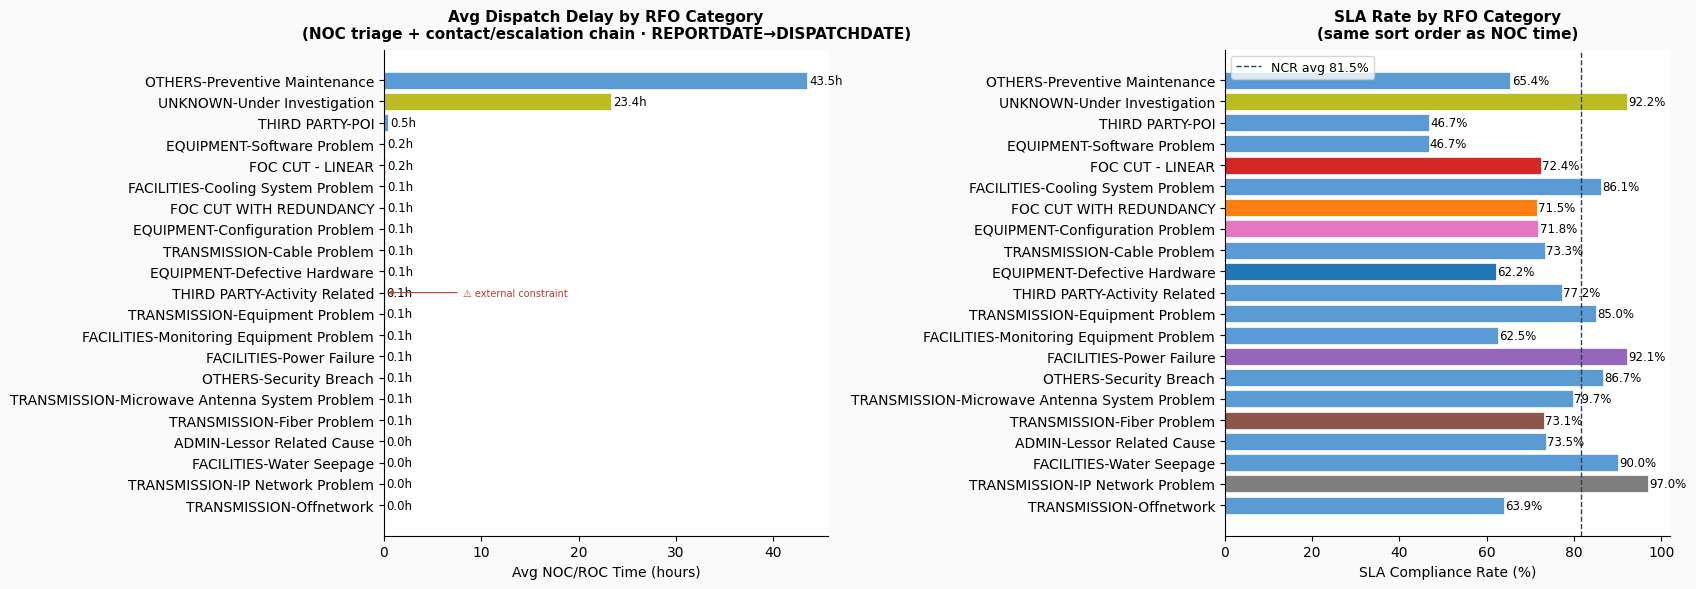

Dispatch Delay by RFO (timestamp-clean, ≥30 tickets):
Note: high values reflect NOC contact/escalation chain, not triage speed alone.
                             Standardized RFO  Ticket_Count  Avg_NOC_Time  SLA_Rate
                OTHERS-Preventive Maintenance            81          43.5      65.4
                  UNKNOWN-Under Investigation          4807          23.4      92.2
                              THIRD PARTY-POI           227           0.5      46.7
                   EQUIPMENT-Software Problem            30           0.2      46.7
                             FOC CUT - LINEAR          3696           0.2      72.4
            FACILITIES-Cooling System Problem          2087           0.1      86.1
                      FOC CUT WITH REDUNDANCY           520           0.1      71.5
              EQUIPMENT-Configuration Problem           731           0.1      71.8
                   TRANSMISSION-Cable Problem           348           0.1      73.3
                 EQUIPMENT

In [5]:
# DISPATCH_DELAY_HOURS by RFO — NOC triage + contact/escalation chain duration
# (assigned engr → duty team lead → area head if unreachable)
# DISPATCHDATE stamped at endorsement, NOT at physical departure — mobilisation
# coordination after this point flows into FIELD_TIME_HOURS.
# Timestamp-clean tickets only.
clean_all = df_zone[df_zone['Timestamp_Integrity']].copy()

rfo_noc = (clean_all.groupby('Standardized RFO')
            .agg(
                Avg_NOC_Time=('DISPATCH_DELAY_HOURS', 'mean'),
                Ticket_Count=('DISPATCH_DELAY_HOURS', 'count'),
                SLA_Rate=('SLA_Compliant', 'mean')
            )
            .reset_index()
            .sort_values('Avg_NOC_Time', ascending=False))

# Filter to RFOs with meaningful volume
rfo_noc = rfo_noc[rfo_noc['Ticket_Count'] >= 30]
rfo_noc['SLA_Rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.patch.set_facecolor('#fafafa')

colors_noc = [RFO_PALETTE.get(r, '#5b9bd5') for r in rfo_noc['Standardized RFO']]

# [Left] Avg NOC time
bars = axes[0].barh(rfo_noc['Standardized RFO'], rfo_noc['Avg_NOC_Time'],
                     color=colors_noc, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, rfo_noc['Avg_NOC_Time']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}h', va='center', fontsize=8.5)
axes[0].set_xlabel('Avg NOC/ROC Time (hours)', fontsize=10)
axes[0].set_title('Avg Dispatch Delay by RFO Category\n'
                  '(NOC triage + contact/escalation chain · REPORTDATE→DISPATCHDATE)',
                  fontsize=11, fontweight='bold', pad=8)
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Annotate third-party and force majeure as external-constraint categories
external = ['THIRD PARTY-Activity Related', 'OTHERS-Force Majeure']
for bar, rfo in zip(bars, rfo_noc['Standardized RFO']):
    if rfo in external:
        axes[0].annotate('⚠ external constraint',
                         xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                         xytext=(bar.get_width() + 8, bar.get_y() + bar.get_height()/2),
                         fontsize=7, color='#c0392b', va='center',
                         arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.8))

# [Right] SLA rate by RFO (ordered same as left)
axes[1].barh(rfo_noc['Standardized RFO'], rfo_noc['SLA_Rate'],
              color=colors_noc, edgecolor='white', linewidth=0.5)
ncr_sla_avg = clean_all['SLA_Compliant'].mean() * 100
axes[1].axvline(ncr_sla_avg, color='#2c3e50', linestyle='--',
                linewidth=1, label=f'NCR avg {ncr_sla_avg:.1f}%')
for bar, val in zip(axes[1].patches, rfo_noc['SLA_Rate']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=8.5)
axes[1].set_xlabel('SLA Compliance Rate (%)', fontsize=10)
axes[1].set_title('SLA Rate by RFO Category\n(same sort order as NOC time)',
                  fontsize=11, fontweight='bold', pad=8)
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/07_rfo_noc_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print('Dispatch Delay by RFO (timestamp-clean, ≥30 tickets):')
print('Note: high values reflect NOC contact/escalation chain, not triage speed alone.')
print(rfo_noc[['Standardized RFO','Ticket_Count','Avg_NOC_Time','SLA_Rate']]
      .to_string(index=False, float_format='{:.1f}'.format))
print(f'\n⚠ External-constraint RFOs (high dispatch delay driven by external coordination):')
for rfo in external:
    row = rfo_noc[rfo_noc['Standardized RFO'] == rfo]
    if len(row):
        print(f'  {rfo}: {row["Avg_NOC_Time"].values[0]:.1f}h avg NOC time')
    else:
        print(f'  {rfo}: < 30 tickets (below volume threshold)')

## 5. NE Category Distribution by Zone

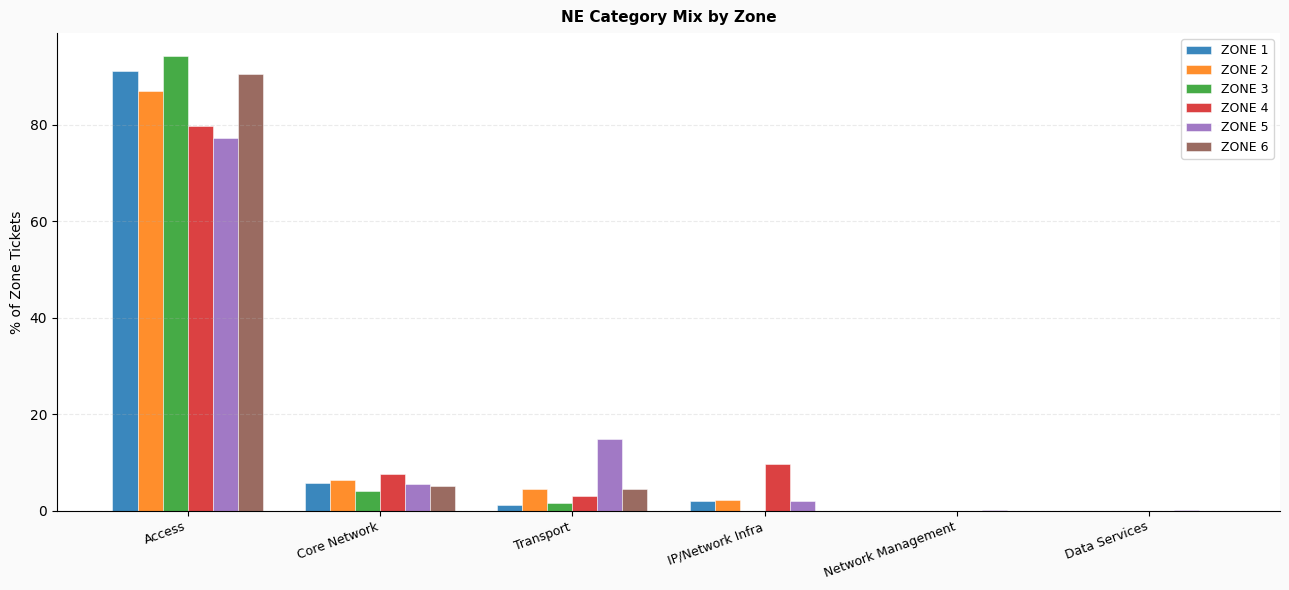

In [6]:
ne_zone = (df_zone.groupby(['ZONE', 'NE_Category'])
            .size()
            .reset_index(name='Count'))
ne_zone['Zone_Total'] = ne_zone.groupby('ZONE')['Count'].transform('sum')
ne_zone['Pct'] = ne_zone['Count'] / ne_zone['Zone_Total'] * 100

ne_pivot = (ne_zone.pivot_table(index='NE_Category', columns='ZONE',
                                 values='Pct', fill_value=0)
             .reindex(columns=ZONE_ORDER))

# Sort by NCR total
ne_pivot['_total'] = ne_pivot.sum(axis=1)
ne_pivot = ne_pivot.sort_values('_total', ascending=False).drop(columns='_total')

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafafa')

ne_cats = ne_pivot.index.tolist()
x = np.arange(len(ne_cats)); w = 0.13
zone_palette = [ZONE_COLORS.get(z, '#888') for z in ZONE_ORDER]

for i, (zone, color) in enumerate(zip(ZONE_ORDER, zone_palette)):
    vals = ne_pivot[zone].values
    offset = (i - len(ZONE_ORDER)/2 + 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=zone, color=color,
                  edgecolor='white', linewidth=0.4, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(ne_cats, fontsize=9, rotation=20, ha='right')
ax.set_ylabel('% of Zone Tickets', fontsize=10)
ax.set_title('NE Category Mix by Zone', fontsize=11, fontweight='bold', pad=8)
ax.legend(fontsize=9, framealpha=0.8, loc='upper right')
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/07_ne_category_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. NE Category vs Field Time

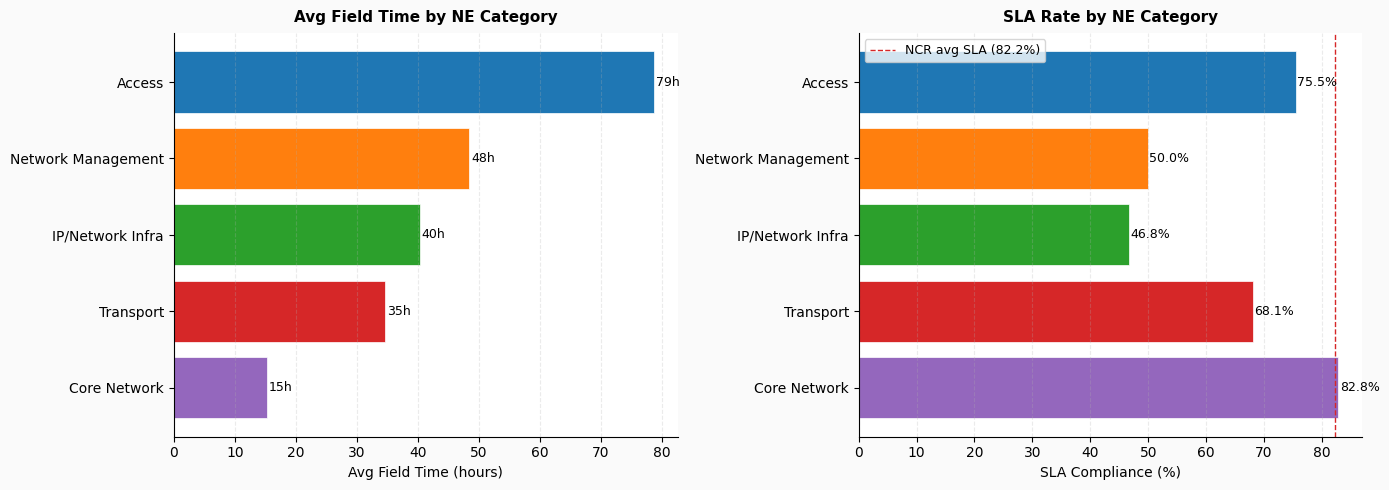


NE Category field time + SLA summary:
       NE_Category  Avg_Field_Time  Ticket_Count  SLA_Rate
            Access       78.634616         19957 75.467255
Network Management       48.391622             6 50.000000
  IP/Network Infra       40.266245            77 46.753247
         Transport       34.628962          1089 68.135904
      Core Network       15.299299           816 82.843137


In [7]:
ne_field = (clean_fd.groupby('NE_Category')
             .agg(
                 Avg_Field_Time=('FIELD_TIME_HOURS', 'mean'),
                 Ticket_Count=('FIELD_TIME_HOURS', 'count'),
                 SLA_Rate=('SLA_Compliant', 'mean')
             )
             .reset_index()
             .sort_values('Avg_Field_Time', ascending=False))
ne_field['SLA_Rate'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#fafafa')

ne_colors = PROFESSIONAL_PALETTE[:len(ne_field)]

bars = axes[0].barh(ne_field['NE_Category'], ne_field['Avg_Field_Time'],
                     color=ne_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ne_field['Avg_Field_Time']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}h', va='center', fontsize=9)
axes[0].set_xlabel('Avg Field Time (hours)', fontsize=10)
axes[0].set_title('Avg Field Time by NE Category', fontsize=11, fontweight='bold', pad=8)
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', alpha=0.25, linestyle='--')

bars2 = axes[1].barh(ne_field['NE_Category'], ne_field['SLA_Rate'],
                      color=ne_colors, edgecolor='white', linewidth=0.5)
ncr_sla_avg = df_zone['SLA_Compliant'].mean() * 100
axes[1].axvline(ncr_sla_avg, color='#d62728', linestyle='--', linewidth=1,
               label=f'NCR avg SLA ({ncr_sla_avg:.1f}%)')
for bar, val in zip(bars2, ne_field['SLA_Rate']):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('SLA Compliance (%)', fontsize=10)
axes[1].set_title('SLA Rate by NE Category', fontsize=11, fontweight='bold', pad=8)
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='x', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/07_ne_field_time_sla.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNE Category field time + SLA summary:")
print(ne_field.to_string(index=False))

## 7. Zone 5 vs Zone 6 Fault Fingerprint — Direct Comparison

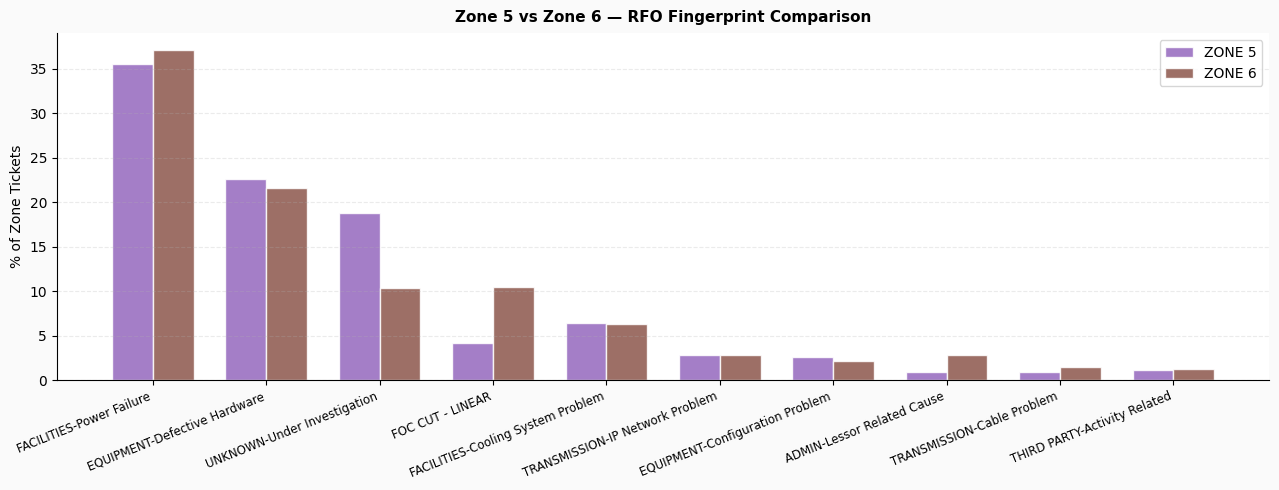


Field time by RFO — Zone 5 and Zone 6 (≥20 tickets):

  ZONE 5:
    ADMIN-Lessor Related Cause                    413h  (24 tickets)
    EQUIPMENT-Defective Hardware                  253h  (1626 tickets)
    EQUIPMENT-Configuration Problem               221h  (166 tickets)
    OTHERS-Preventive Maintenance                 220h  (21 tickets)
    FOC CUT WITH REDUNDANCY                       166h  (57 tickets)
    UNKNOWN-Under Investigation                   151h  (106 tickets)
    THIRD PARTY-Activity Related                  105h  (60 tickets)
    FOC CUT - LINEAR                              55h  (230 tickets)
    TRANSMISSION-Microwave Antenna System Problem 54h  (50 tickets)
    FACILITIES-Power Failure                      43h  (1577 tickets)
    TRANSMISSION-Cable Problem                    39h  (80 tickets)
    FACILITIES-Cooling System Problem             34h  (564 tickets)

  ZONE 6:
    FOC CUT WITH REDUNDANCY                       263h  (39 tickets)
    EQUIPMENT-Configurat

In [8]:
# Zone 5 and Zone 6 are both field-bottlenecked underperformers.
# Do they share the same fault type profile, or is Zone 6 structurally different?
z56 = df_zone[df_zone['ZONE'].isin(['ZONE 5','ZONE 6'])].copy()

rfo_56 = (z56.groupby(['ZONE','Standardized RFO']).size()
            .reset_index(name='Count'))
rfo_56['Zone_Total'] = rfo_56.groupby('ZONE')['Count'].transform('sum')
rfo_56['Pct'] = rfo_56['Count'] / rfo_56['Zone_Total'] * 100

# Top 10 RFOs across both zones
top10 = (rfo_56.groupby('Standardized RFO')['Count'].sum()
          .nlargest(10).index.tolist())

rfo_56_top = rfo_56[rfo_56['Standardized RFO'].isin(top10)]
z5_rfo = rfo_56_top[rfo_56_top['ZONE']=='ZONE 5'].set_index('Standardized RFO')['Pct']
z6_rfo = rfo_56_top[rfo_56_top['ZONE']=='ZONE 6'].set_index('Standardized RFO')['Pct']

compare = pd.DataFrame({'ZONE 5': z5_rfo, 'ZONE 6': z6_rfo}).fillna(0)
compare = compare.reindex(compare.mean(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')

x = np.arange(len(compare)); w = 0.36
ax.bar(x - w/2, compare['ZONE 5'], w, label='ZONE 5', color='#9467bd', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, compare['ZONE 6'], w, label='ZONE 6', color='#8c564b', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(compare.index, fontsize=8.5, rotation=22, ha='right')
ax.set_ylabel('% of Zone Tickets', fontsize=10)
ax.set_title('Zone 5 vs Zone 6 — RFO Fingerprint Comparison',
             fontsize=11, fontweight='bold', pad=8)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project2_ncr/07_z5_z6_rfo_compare.png', dpi=150, bbox_inches='tight')
plt.show()

# RFO × zone field time for Z5 and Z6
rfo_z56_ft = (clean_fd[clean_fd['ZONE'].isin(['ZONE 5','ZONE 6'])]
               .groupby(['ZONE','Standardized RFO'])['FIELD_TIME_HOURS']
               .agg(['mean','count'])
               .reset_index()
               .rename(columns={'mean':'Avg_Field_Time','count':'Tickets'})
               .query('Tickets >= 20')
               .sort_values(['ZONE','Avg_Field_Time'], ascending=[True, False]))

print("\nField time by RFO — Zone 5 and Zone 6 (≥20 tickets):")
for zone in ['ZONE 5', 'ZONE 6']:
    subset = rfo_z56_ft[rfo_z56_ft['ZONE']==zone]
    print(f"\n  {zone}:")
    for _, row in subset.iterrows():
        print(f"    {row['Standardized RFO']:<45} {row['Avg_Field_Time']:.0f}h  ({int(row['Tickets'])} tickets)")

## 8. Key Findings

### RFO Field Time (Section 4)
- Equipment-Defective Hardware and Configuration Problem are the slowest RFOs to resolve on-site
- Facilities-Power Failure dominates volume (35.4% NCR-wide) with moderate field time — high impact on absolute breach count

### RFO Dispatch Delay / NOC-to-Endorsement Time (Section 4b)
- `DISPATCH_DELAY_HOURS` captures NOC triage **plus** the full contact and escalation chain: up to 3 attempts to reach the assigned engineer, then duty team lead, then area head if still unreachable
- **THIRD PARTY-Activity Related** and **OTHERS-Force Majeure** carry the longest dispatch delays — driven by external coordination requirements (third-party contractors, disaster response) outside NOC/field control
- These categories should be **excluded from operational dispatch delay targets** — zones with higher third-party or force majeure exposure will appear worse on this metric for non-operational reasons
- All internally-driven RFO categories (Equipment, Facilities, Transmission, FOC) show consistently low dispatch delays — the NOC contact and triage process for standard fault types is not a bottleneck
- **Mobilisation note:** `DISPATCH_DELAY_HOURS` ends at endorsement timestamp. For day-off scenarios, the assigned engineer's coordination after receiving the call (locating a duty engineer, briefing a team lead who also has their own assigned sites) continues into `FIELD_TIME_HOURS`. The two metrics together form the complete mobilisation picture — neither alone isolates the full day-off endorsement delay

→ **Notebook 08** — Zone 1 Site Risk Profiling: identifying top recurring-fault sites for preventive maintenance.

In [9]:
# Print structured findings to carry forward into NB09 summary
print("=" * 70)
print("NOTEBOOK 07 — KEY FINDINGS")
print("=" * 70)

# Dominant RFO NCR-wide
top3_rfo = df_zone['Standardized RFO'].value_counts().head(3)
print(f"\nNCR Top 3 RFOs:")
for rfo, count in top3_rfo.items():
    print(f"  {rfo:<45} {count:,}  ({count/len(df_zone)*100:.1f}%)")

# Slowest RFOs by field time
print(f"\nSlowest field time RFOs (Field Dispatch · clean):")
for _, row in rfo_field.head(5).iterrows():
    print(f"  {row['Standardized RFO']:<45} {row['Avg_Field_Time']:.0f}h  SLA {row['SLA_Rate']:.1f}%")

# Slowest NE categories
print(f"\nSlowest field time NE categories:")
for _, row in ne_field.head(4).iterrows():
    print(f"  {row['NE_Category']:<25} {row['Avg_Field_Time']:.0f}h  SLA {row['SLA_Rate']:.1f}%")

print(f"\nZone 5 vs Zone 6 RFO similarity:")
overlap = set(compare[compare['ZONE 5']>5].index) & set(compare[compare['ZONE 6']>5].index)
print(f"  Shared high-volume RFOs (>5% in both zones): {len(overlap)}")
for rfo in overlap:
    print(f"    {rfo}  |  Z5: {compare.loc[rfo,'ZONE 5']:.1f}%  Z6: {compare.loc[rfo,'ZONE 6']:.1f}%")

NOTEBOOK 07 — KEY FINDINGS

NCR Top 3 RFOs:
  FACILITIES-Power Failure                      13,055  (35.4%)
  EQUIPMENT-Defective Hardware                  7,921  (21.5%)
  UNKNOWN-Under Investigation                   5,129  (13.9%)

Slowest field time RFOs (Field Dispatch · clean):
  THIRD PARTY-Activity Related                  189h  SLA 74.3%
  ADMIN-Lessor Related Cause                    182h  SLA 32.5%
  OTHERS-Preventive Maintenance                 179h  SLA 71.4%
  EQUIPMENT-Configuration Problem               160h  SLA 73.9%
  EQUIPMENT-Defective Hardware                  136h  SLA 57.4%

Slowest field time NE categories:
  Access                    79h  SLA 75.5%
  Network Management        48h  SLA 50.0%
  IP/Network Infra          40h  SLA 46.8%
  Transport                 35h  SLA 68.1%

Zone 5 vs Zone 6 RFO similarity:
  Shared high-volume RFOs (>5% in both zones): 4
    FACILITIES-Power Failure  |  Z5: 35.6%  Z6: 37.2%
    EQUIPMENT-Defective Hardware  |  Z5: 22.7%  Z6: